In [2]:
import sys
sys.path.append("/Users/emilieyu/endotehelial-masboss")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import copy

from abm.rho_lookup_table import RhoLookupTable
from src.config import load_abm_sim_cfg, load_bm_sweep_cfg
from src.paths import BM_RESULTS_DIR

from abm.scripts.run_abm_sim import run_abm_sim, run_abm_sim_single, perturbation_cfg, plot_cell

sim_cfg = load_abm_sim_cfg()
lut = RhoLookupTable(sim_cfg, BM_RESULTS_DIR)
perbs = sim_cfg['perturbations']

>>> DEBUG: Successfully loaded recruitment parameter sweep data.
>>> DEBUG: Successfully built interpolators
LUT ready | rest: RhoA=0.395 RhoC=0.406


In [3]:
dsp_cfg = perturbation_cfg(sim_cfg, perbs['DSP_KO'])
tjp1_cfg = perturbation_cfg(sim_cfg, perbs['TJP1_KO'])
jcad_cfg = perturbation_cfg(sim_cfg, perbs['JCAD_KO'])
tjp1_jcad_cfg = perturbation_cfg(sim_cfg, perbs['TJP1_JCAD_DKO'])
dsp_jcad_cfg = perturbation_cfg(sim_cfg, perbs['DSP_JCAD_DKO'])

>>> INFO: Running perturbation: WT for 1500 steps.


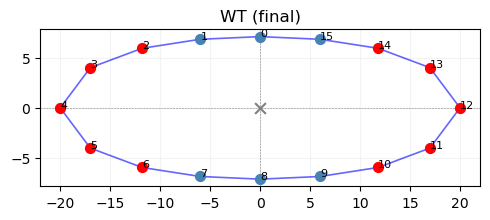

 WT ar=2.805 | rho_balance=-0.031 | rhoa=0.573 | rhoc=0.542 | t=1.9s


In [4]:
res_wt = run_abm_sim_single(sim_cfg, lut, 'WT', True)

In [5]:
pd.DataFrame(res_wt['node_ss'])
#pd.DataFrame(res_wt['spring_ss'])

,step,time,perturbation,id,position,tensile_load,shear_total,DSP,TJP1,JCAD,rhoa,rhoc,classification
0,1499,149.9,WT,0,"(-0.0, 7.14)",22.107814,10.0,0.435140,0.368455,0.577586,0.556509,0.522394,lateral
1,1499,149.9,WT,1,"(-6.0, 6.87)",21.801314,10.0,0.428712,0.363818,0.577586,0.555723,0.521190,lateral
2,1499,149.9,WT,2,"(-11.81, 5.97)",32.142270,10.0,0.569909,0.482996,0.577586,0.580731,0.543866,polar
3,1499,149.9,WT,3,"(-17.0, 4.03)",42.077577,10.0,0.621358,0.546527,0.577586,0.584907,0.558629,polar
4,1499,149.9,WT,4,"(-20.02, 0.0)",49.836033,10.0,0.639851,0.577062,0.577586,0.584575,0.567805,polar
5,1499,149.9,WT,5,"(-17.0, -4.03)",42.077577,10.0,0.621358,0.546527,0.577586,0.584907,0.558629,polar
6,1499,149.9,WT,6,"(-11.81, -5.97)",32.142270,10.0,0.569909,0.482996,0.577586,0.580731,0.543866,polar
7,1499,149.9,WT,7,"(-6.0, -6.87)",21.801314,10.0,0.428712,0.363818,0.577586,0.555723,0.521190,lateral
8,1499,149.9,WT,8,"(-0.0, -7.14)",22.107814,10.0,0.435140,0.368455,0.577586,0.556509,0.522394,lateral
9,1499,149.9,WT,9,"(6.0, -6.87)",21.801314,10.0,0.428712,0.363818,0.577586,0.555723,0.521190,lateral


>>> INFO: Running perturbation: JCAD for 1500 steps.


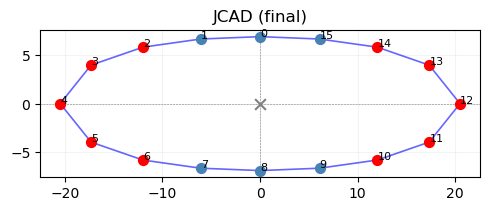

 JCAD ar=2.985 | rho_balance=-0.025 | rhoa=0.496 | rhoc=0.471 | t=1.6s


In [8]:
res_jcad = run_abm_sim_single(jcad_cfg, lut, 'JCAD', True)

In [ ]:
pd.DataFrame(res_jcad['node_ss'])
pd.DataFrame(res_jcad['spring_ss'])

>>> INFO: Running perturbation: DSP for 1500 steps.


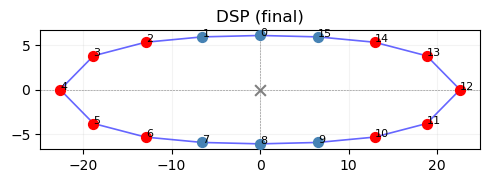

 DSP ar=3.689 | rho_balance=0.463 | rhoa=0.239 | rhoc=0.702 | t=1.6s


In [9]:
res_dsp = run_abm_sim_single(dsp_cfg, lut, 'DSP', True)

In [ ]:
pd.DataFrame(res_dsp['node_ss'])
#pd.DataFrame(res_dsp['spring_ss'])

>>> INFO: Running perturbation: DSP_JCAD for 1500 steps.


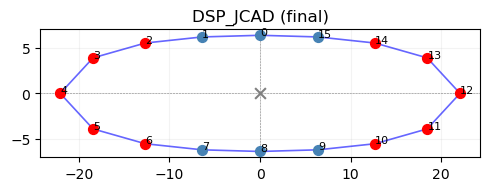

 DSP_JCAD ar=3.441 | rho_balance=0.285 | rhoa=0.301 | rhoc=0.586 | t=1.5s


In [10]:
res_dsp_jcad = run_abm_sim_single(dsp_jcad_cfg, lut, 'DSP_JCAD', True)

In [ ]:
pd.DataFrame(res_dsp_jcad['node_ss'])
#pd.DataFrame(res_dsp_jcad['spring_ss'])

>>> INFO: Running perturbation: TJP1 for 1500 steps.


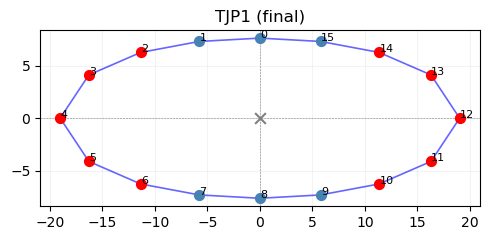

 TJP1 ar=2.494 | rho_balance=-0.494 | rhoa=0.720 | rhoc=0.227 | t=1.8s


In [11]:
res_tjp1 = run_abm_sim_single(tjp1_cfg, lut, 'TJP1', True)

In [ ]:
pd.DataFrame(res_tjp1['node_ss'])
#pd.DataFrame(res_tjp1['spring_ss'])

>>> INFO: Running perturbation: TJP1_JCAD for 1500 steps.


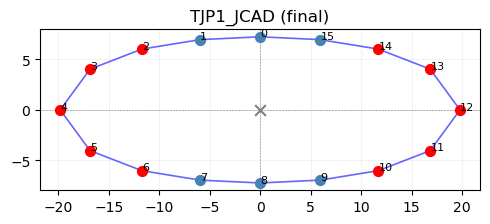

 TJP1_JCAD ar=2.735 | rho_balance=-0.299 | rhoa=0.595 | rhoc=0.295 | t=1.7s


In [12]:
res_tjp1_jcad = run_abm_sim_single(tjp1_jcad_cfg, lut, 'TJP1_JCAD', True)

In [ ]:
pd.DataFrame(res_tjp1_jcad['node_ss'])
#pd.DataFrame(tjp1_jcad_cfg['spring_ss'])

In [6]:
_, _, _, ss_df = run_abm_sim(sim_cfg, lut)

>>> INFO: Running perturbation: WT for 1500 steps.
 WT ar=2.805 | rho_balance=-0.031 | rhoa=0.573 | rhoc=0.542 | t=1.6s
>>> INFO: Running perturbation: DSP_KO for 1500 steps.
 DSP_KO ar=3.689 | rho_balance=0.463 | rhoa=0.239 | rhoc=0.702 | t=1.4s
>>> INFO: Running perturbation: TJP1_KO for 1500 steps.
 TJP1_KO ar=2.494 | rho_balance=-0.494 | rhoa=0.720 | rhoc=0.227 | t=1.6s
>>> INFO: Running perturbation: JCAD_KO for 1500 steps.
 JCAD_KO ar=2.985 | rho_balance=-0.025 | rhoa=0.496 | rhoc=0.471 | t=1.4s
>>> INFO: Running perturbation: DSP_JCAD_DKO for 1500 steps.
 DSP_JCAD_DKO ar=3.441 | rho_balance=0.285 | rhoa=0.301 | rhoc=0.586 | t=1.4s
>>> INFO: Running perturbation: TJP1_JCAD_DKO for 1500 steps.
 TJP1_JCAD_DKO ar=2.735 | rho_balance=-0.299 | rhoa=0.595 | rhoc=0.295 | t=1.6s


In [7]:
ss_df

,step,time,perturbation,cell_id,ar,area_ratio,perimeter,major,minor,t_load_polar,...,dsp_lateral,cortex_T_polar,cortex_T_lateral,cortex_k_polar,cortex_k_lateral,cortex_a_mean,sf_T,sf_a,sf_k,sf_squeeze_total
0,1499,149.9,WT,0,2.805,1.0101,89.834,40.033,14.273,39.655,...,0.431,1.998,3.027,1.584,1.556,0.865,16.7079,0.676,0.7,5.0124
1,1499,149.9,DSP_KO,0,3.689,0.9954,97.549,45.119,12.232,43.289,...,0.000,1.765,2.837,1.225,1.258,0.914,20.9272,0.636,0.7,6.2782
2,1499,149.9,TJP1_KO,0,2.494,1.0176,87.105,38.029,15.248,37.009,...,0.438,2.139,3.114,1.734,1.701,0.843,13.9960,0.754,0.7,4.1988
3,1499,149.9,JCAD_KO,0,2.985,0.9960,90.975,40.956,13.721,39.521,...,0.425,1.883,2.953,1.502,1.487,0.876,17.0536,0.693,0.7,5.1161
4,1499,149.9,DSP_JCAD_DKO,0,3.441,1.0143,96.149,44.113,12.819,42.216,...,0.000,1.845,2.866,1.289,1.318,0.905,19.7443,0.665,0.7,5.9233
5,1499,149.9,TJP1_JCAD_DKO,0,2.735,1.0113,89.225,39.613,14.483,37.639,...,0.428,1.913,2.997,1.609,1.573,0.861,15.2647,0.737,0.7,4.5794
